# Assumption of Lenear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('E:/Dataset/data.csv')

In [3]:
df.sample(5)

,feature1,feature2,feature3,target
165,0.265787,-0.912091,-0.571349,5.343081
30,-0.464669,0.418381,-0.231905,-44.390240
96,0.225750,0.287035,-1.744110,-95.368287
156,-0.527188,-0.321585,-0.095238,-80.321397
175,-0.277388,-0.354759,-1.863493,-109.204180


In [4]:
df.shape

(200, 4)

In [5]:
x = df.iloc[:,:3]
y = df.iloc[:,-1]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [8]:
x_train.sample(2)

,feature1,feature2,feature3
7,0.663188,0.185268,-1.883424
133,-1.886837,0.096594,0.254388


In [9]:
x_train.shape

(160, 3)

In [10]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = lr.predict(x_test)

#### Residual

In [22]:
residual = y_test - y_pred  # Error in the actual output, and predicted output
# residual

### i) Linear Relationship

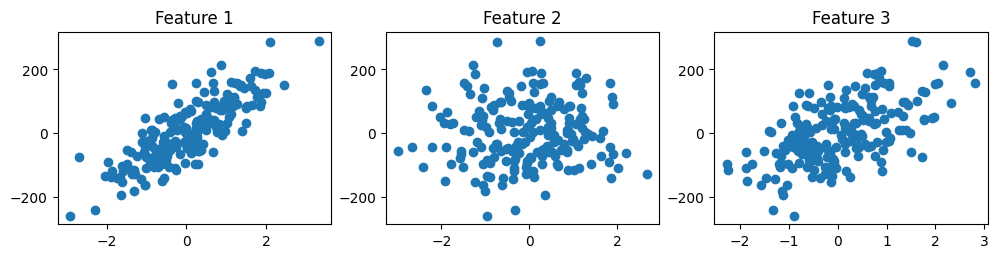

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title('Feature 1')

ax2.scatter(df['feature2'], df['target'])
ax2.set_title('Feature 2')

ax3.scatter(df['feature3'], df['target'])
ax3.set_title('Feature 3')
plt.show()

### ii) Features should **not** be **multicolinear**

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [15]:
vif = []
for i in range(x_train.shape[1]):
    vif.append(variance_inflation_factor(x_train, 1))

In [23]:
vif

[np.float64(1.0052736607332795),
 np.float64(1.0052736607332795),
 np.float64(1.0052736607332795)]

In [16]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3])

,vif
feature1,1.005274
feature2,1.005274
feature3,1.005274


#### Another method

<Axes: >

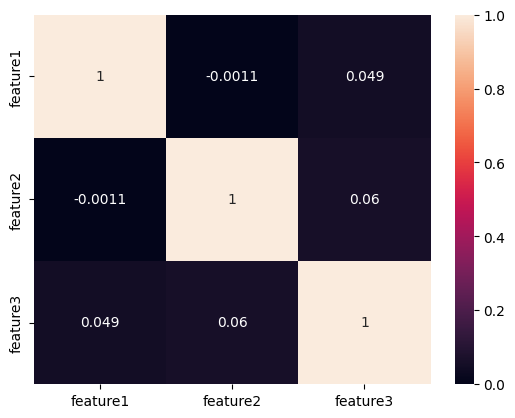

In [28]:
sns.heatmap(df.iloc[:, 0:3].corr(), annot=True)

### iii) Residual(error) should be normally distributed

In [41]:
residual = y_test - y_pred

<Axes: xlabel='target', ylabel='Density'>

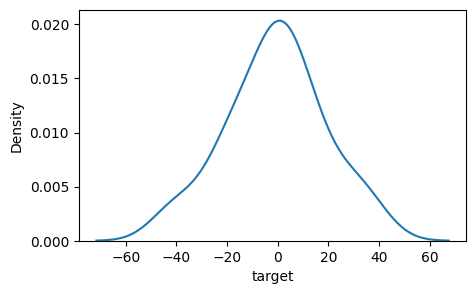

In [42]:
plt.figure(figsize=(5,3))
sns.kdeplot(residual)

In [43]:
residual.skew()

np.float64(-0.11428514916267302)

#### Another method (QQ plot)

In [31]:
import scipy as sp

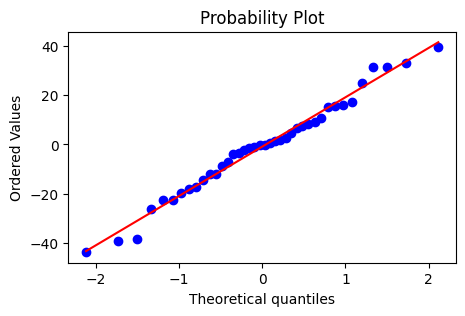

In [44]:
fig, ax = plt.subplots(figsize=(5,3))
sp.stats.probplot(residual, plot=ax, fit=True)
plt.show()

### iv) Homoscedasticity (Homogeneous scatter)

Text(0, 0.5, 'Reidual')

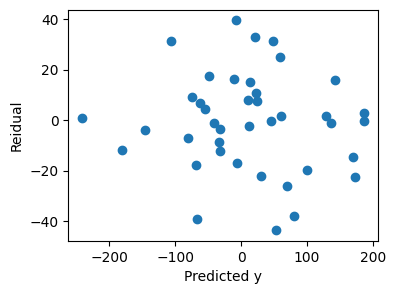

In [49]:
plt.figure(figsize=(4,3))
plt.scatter(y_pred, residual)
plt.xlabel('Predicted y')
plt.ylabel('Reidual')

### v) No any autocorrelation of Error

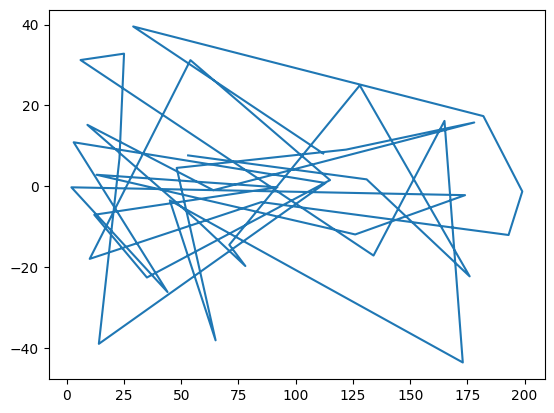

In [50]:
plt.plot(residual)